误码率 BER = 0.006


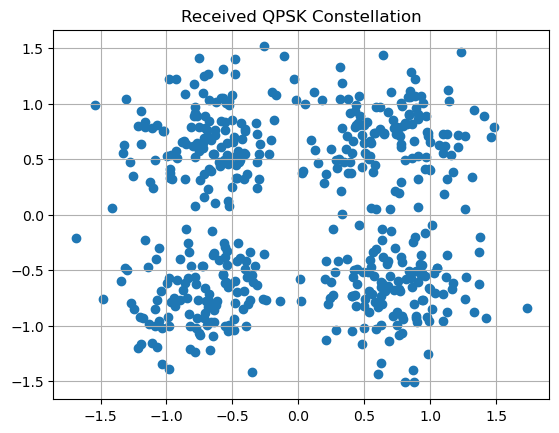

In [2]:
import numpy as np
import matplotlib.pyplot as plt
#numpy：用来生成随机数、存数组（通信里大量用数组）
#matplotlib：用来画图（星座图）

# 生成随机比特
N = 1000   #要发送1000个比特（bit）
bits = np.random.randint(0, 2, N)   #从 0 到 1（不包含2）随机生成 N 个整数

# QPSK 调制
symbols = []  

for i in range(0, N, 2):  #从 0 开始，到 N-1 结束，每次跳 2
    b1 = bits[i]
    b2 = bits[i+1]

    if b1 == 0 and b2 == 0:
        symbols.append(1+1j)
    elif b1 == 0 and b2 == 1:
        symbols.append(1-1j)
    elif b1 == 1 and b2 == 0:
        symbols.append(-1+1j)
    else:
        symbols.append(-1-1j)

symbols = np.array(symbols) / np.sqrt(2)
#np.array(symbols)：把 Python list 变成 numpy 数组

# 加噪声
noise = 0.3*(np.random.randn(len(symbols)) + 1j*np.random.randn(len(symbols)))

rx = symbols + noise
#信道会引入噪声/干扰

# 解调，看落在哪个象限
rx_bits = []

for s in rx:
    if s.real > 0:
        b1 = 0
    else:
        b1 = 1
        
    if s.imag > 0:
        b2 = 0
    else:
        b2 = 1
        
    rx_bits.extend([b1, b2])

rx_bits = np.array(rx_bits)

# 计算误码率
errors = np.sum(bits != rx_bits)
ber = errors / N

print("误码率 BER =", ber)

# 画星座图
plt.scatter(rx.real, rx.imag)
plt.grid()
plt.title("Received QPSK Constellation")
plt.show()